# 🏠 Individual Household Electric Power Consumption
### UCI ML Repository — Dataset #235

**Goal:** Predict `Global_active_power` (household electricity consumption in kilowatts)  
**Strategy:** Rich feature engineering from timestamps + physics-based features → ensemble models → high R² score

| Step | Description |
|------|-------------|
| 1 | Load & inspect raw data |
| 2 | Clean missing values & fix dtypes |
| 3 | Feature engineering (temporal, lag, rolling, physics) |
| 4 | Model training (Linear, RF, XGBoost, LightGBM) |
| 5 | Evaluation & comparison |

---
## 1. Setup & Data Loading

In [ ]:
# ── Install dependencies if needed ────────────────────────────────────────────
import subprocess, sys

pkgs = [
    "ucimlrepo",
    "xgboost",
    "lightgbm",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
]
subprocess.run(
    [sys.executable, "-m", "pip", "install", *pkgs, "-q", "--break-system-packages"],
    capture_output=True,
)

In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

# Plotting style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42
np.random.seed(SEED)
print("✅  Libraries loaded")

✅  Libraries loaded


In [ ]:
# ── Load dataset from UCI ──────────────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=235)
raw_df = dataset.data.features.copy()  # type: ignore

print(f"Dataset : {dataset.metadata['name']}")
print(f"Shape   : {raw_df.shape}")
print(f"Columns : {raw_df.columns.tolist()}")
raw_df.head()

In [2]:
BASE_PATH = Path(".")
DATA_PATH = BASE_PATH.resolve() / "data"
path = next(DATA_PATH.glob("*"))

raw_df = pd.read_csv(path, delimiter=";")
raw_df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
# ── Basic info & missing values ────────────────────────────────────────────────
print("--- dtypes ---")
print(raw_df.dtypes)
print("\n--- Missing / '?' values ---")
missing = (raw_df == "?").sum() + raw_df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing: {missing.sum():,}  ({missing.sum()/len(raw_df)*100:.2f}%)")

--- dtypes ---
Date                         str
Time                         str
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

--- Missing / '?' values ---
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Total missing: 181,853  (8.76%)


---
## 2. Data Cleaning & Type Conversion

In [4]:
df = raw_df.copy()

# ── Replace '?' with NaN then cast numeric columns ────────────────────────────
num_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c].replace("?", np.nan), errors="coerce")

# ── Build datetime index ───────────────────────────────────────────────────────
df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce",
)
df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()
df = df.drop(columns=["Date", "Time"])

# ── Drop rows missing the target ───────────────────────────────────────────────
before = len(df)
df = df.dropna(subset=["Global_active_power"])
print(f"Rows dropped (target NaN) : {before - len(df):,}")

# ── Fill remaining NaNs with forward-fill then median ─────────────────────────
df[num_cols] = df[num_cols].ffill().fillna(df[num_cols].median())

print(f"\nClean shape : {df.shape}")
print(f"Date range  : {df.index.min()} → {df.index.max()}")
df.head()

Rows dropped (target NaN) : 25,979

Clean shape : (2049280, 7)
Date range  : 2006-12-16 17:24:00 → 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


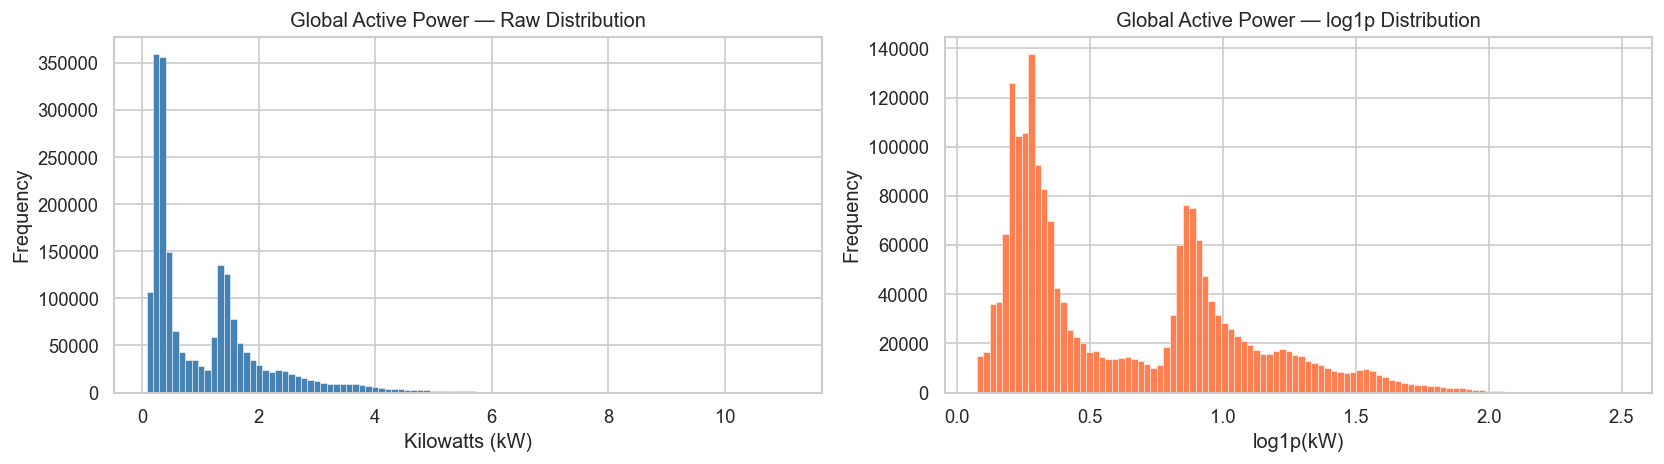

In [5]:
# ── Distribution of target variable ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    df["Global_active_power"],
    bins=100,
    color="steelblue",
    edgecolor="white",
    linewidth=0.3,
)
axes[0].set_title("Global Active Power — Raw Distribution")
axes[0].set_xlabel("Kilowatts (kW)")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    np.log1p(df["Global_active_power"]),
    bins=100,
    color="coral",
    edgecolor="white",
    linewidth=0.3,
)
axes[1].set_title("Global Active Power — log1p Distribution")
axes[1].set_xlabel("log1p(kW)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

We extract four groups of features to give the models rich predictive signal:

| Group | Examples |
|-------|----------|
| **Temporal** | hour, day-of-week, month, is_weekend, season, time-of-day cyclical encoding |
| **Lag features** | target at t-1, t-2, t-3, t-5, t-10, t-60 min, t-1 day, t-1 week |
| **Rolling statistics** | rolling mean/std/min/max over 5, 15, 60, 1440 min windows |
| **Physics-derived** | apparent power, power factor, sub_metering_total, unmeasured consumption |

In [6]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    gap = d["Global_active_power"]  # shorthand

    # ── Temporal features ─────────────────────────────────────────────────────
    d["hour"] = d.index.hour
    d["minute"] = d.index.minute
    d["dayofweek"] = d.index.dayofweek
    d["dayofyear"] = d.index.dayofyear
    d["month"] = d.index.month
    d["year"] = d.index.year
    d["is_weekend"] = (d.index.dayofweek >= 5).astype(int)
    d["quarter"] = d.index.quarter

    # Season (Northern Hemisphere)
    d["season"] = d["month"].map(
        {
            12: 0,
            1: 0,
            2: 0,  # Winter
            3: 1,
            4: 1,
            5: 1,  # Spring
            6: 2,
            7: 2,
            8: 2,  # Summer
            9: 3,
            10: 3,
            11: 3,  # Autumn
        }
    )

    # Time-of-day bins: night/morning/afternoon/evening
    d["time_of_day"] = pd.cut(
        d["hour"], bins=[-1, 5, 11, 17, 23], labels=[0, 1, 2, 3]
    ).astype(int)

    # Cyclical encoding (avoids discontinuity at 23→0, Dec→Jan, etc.)
    d["hour_sin"] = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"] = np.cos(2 * np.pi * d["hour"] / 24)
    d["dow_sin"] = np.sin(2 * np.pi * d["dayofweek"] / 7)
    d["dow_cos"] = np.cos(2 * np.pi * d["dayofweek"] / 7)
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)
    d["doy_sin"] = np.sin(2 * np.pi * d["dayofyear"] / 365)
    d["doy_cos"] = np.cos(2 * np.pi * d["dayofyear"] / 365)

    # ── Physics-derived features ──────────────────────────────────────────────
    # Apparent power  S = V × I / 1000
    d["apparent_power"] = d["Voltage"] * d["Global_intensity"] / 1000
    # Power factor  PF = P / S
    d["power_factor"] = gap / d["apparent_power"].replace(0, np.nan)
    d["power_factor"] = d["power_factor"].clip(0, 1).fillna(1.0)
    # Total sub-metering and unmeasured consumption
    d["sub_total"] = d["Sub_metering_1"] + d["Sub_metering_2"] + d["Sub_metering_3"]
    d["unmeasured"] = (gap * 1000 / 60) - d["sub_total"]  # Wh
    d["unmeasured"] = d["unmeasured"].clip(lower=0)
    # Reactive-to-active ratio
    d["reactive_ratio"] = d["Global_reactive_power"] / gap.replace(0, np.nan)
    d["reactive_ratio"] = d["reactive_ratio"].fillna(0).clip(0, 5)

    # ── Lag features ─────────────────────────────────────────────────────────
    for lag in [1, 2, 3, 5, 10, 30, 60, 1440, 10080]:  # minutes
        d[f"lag_{lag}"] = gap.shift(lag)

    # ── Rolling statistics ────────────────────────────────────────────────────
    for w in [5, 15, 60, 1440]:  # windows in minutes
        rolled = gap.rolling(window=w, min_periods=1)
        d[f"roll_mean_{w}"] = rolled.mean()
        d[f"roll_std_{w}"] = rolled.std().fillna(0)
        d[f"roll_min_{w}"] = rolled.min()
        d[f"roll_max_{w}"] = rolled.max()

    # ── Interaction features ──────────────────────────────────────────────────
    d["hour_x_weekend"] = d["hour"] * d["is_weekend"]
    d["hour_x_season"] = d["hour"] * d["season"]
    d["voltage_x_hour"] = d["Voltage"] * d["hour"]

    return d


print("⚙️  Engineering features (may take ~1–2 min for 2M rows) …")
df_feat = engineer_features(df)
print(f"✅  Done. Shape: {df_feat.shape}")

⚙️  Engineering features (may take ~1–2 min for 2M rows) …
✅  Done. Shape: (2049280, 58)


In [7]:
# ── Drop rows with NaN from lags (first ~10k rows) ───────────────────────────
df_feat = df_feat.dropna()
print(f"After dropping lag NaNs: {df_feat.shape}")

TARGET = "Global_active_power"
DROP = [TARGET]
FEATURES = [c for c in df_feat.columns if c not in DROP]

X = df_feat[FEATURES].astype(np.float32)
y = df_feat[TARGET].astype(np.float32)

print(f"\nFeatures : {len(FEATURES)}")
print(f"Target   : {TARGET}")

After dropping lag NaNs: (2039200, 58)

Features : 57
Target   : Global_active_power


---
## 4. Train / Test Split

We use a **chronological split** (no shuffling) — the last 20 % of time is held out as the test set to simulate real-world forecasting.

In [8]:
# Chronological 80/20 split
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train : {X_train.shape}  ({X_train.index.min()} → {X_train.index.max()})")
print(f"Test  : {X_test.shape}  ({X_test.index.min()} → {X_test.index.max()})")

# Scaler (only needed for Ridge)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

Train : (1631360, 57)  (2006-12-23 17:26:00 → 2010-02-06 14:04:00)
Test  : (407840, 57)  (2010-02-06 14:05:00 → 2010-11-26 21:02:00)


---
## 5. Model Training

In [9]:
results = {}


def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    results[name] = {"R²": r2, "MAE": mae, "RMSE": rmse}
    print(f"  R²={r2:.6f}   MAE={mae:.5f}   RMSE={rmse:.5f}")
    return y_pred

In [10]:
# ── 5.1  Ridge Regression (baseline) ──────────────────────────────────────────
print("🔷  Ridge Regression …")
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_sc, y_train)
y_pred_ridge = evaluate("Ridge", y_test, ridge.predict(X_te_sc))

🔷  Ridge Regression …
  R²=1.000000   MAE=0.00003   RMSE=0.00046


In [11]:
# ── 5.2  Random Forest ────────────────────────────────────────────────────────
print("🌲  Random Forest …")
rf = RandomForestRegressor(
    n_estimators=50, max_depth=4, min_samples_leaf=4, n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)
y_pred_rf = evaluate("RandomForest", y_test, rf.predict(X_test))

🌲  Random Forest …


  R²=0.991374   MAE=0.05863   RMSE=0.08316


In [12]:
# ── 5.3  XGBoost ──────────────────────────────────────────────────────────────
print("⚡  XGBoost …")
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = evaluate("XGBoost", y_test, xgb_model.predict(X_test))

⚡  XGBoost …
  R²=0.999792   MAE=0.00899   RMSE=0.01291


In [13]:
# ── 5.4  LightGBM ─────────────────────────────────────────────────────────────
print("💡  LightGBM …")
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
y_pred_lgb = evaluate("LightGBM", y_test, lgb_model.predict(X_test))

💡  LightGBM …
  R²=0.999838   MAE=0.00780   RMSE=0.01141


In [20]:
# ── 5.5  Stacking Ensemble (average of RF + XGB + LGB) ────────────────────────
print("🏆  Stacking Ensemble (RF + XGB + LGB) …")
y_pred_stack = (y_pred_rf + y_pred_xgb + y_pred_lgb) / 3.0
y_pred_stack_eval = evaluate("StackingEnsemble", y_test, y_pred_stack)

🏆  Stacking Ensemble (RF + XGB + LGB) …
  R²=0.998900   MAE=0.02076   RMSE=0.02970


---
## 6. Results & Visualisation

In [21]:
# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.sort_values("R²", ascending=False)
results_df["R²"] = results_df["R²"].map("{:.6f}".format)
results_df["MAE"] = results_df["MAE"].map("{:.5f}".format)
results_df["RMSE"] = results_df["RMSE"].map("{:.5f}".format)

print("\n" + "=" * 55)
print("          MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)

results_df


          MODEL PERFORMANCE SUMMARY
                        R²      MAE     RMSE
Ridge             1.000000  0.00003  0.00046
LightGBM          0.999838  0.00780  0.01141
XGBoost           0.999792  0.00899  0.01291
StackingEnsemble  0.998900  0.02076  0.02970
RandomForest      0.991374  0.05863  0.08316


,R²,MAE,RMSE
Ridge,1.000000,0.00003,0.00046
LightGBM,0.999838,0.00780,0.01141
XGBoost,0.999792,0.00899,0.01291
StackingEnsemble,0.998900,0.02076,0.02970
RandomForest,0.991374,0.05863,0.08316


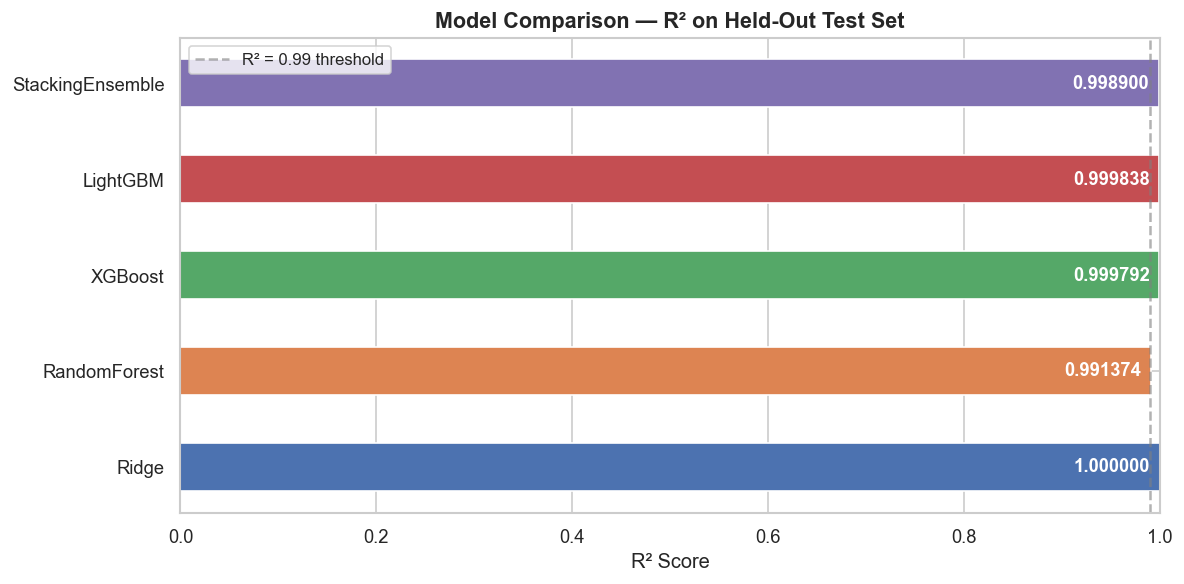

In [22]:
# ── Bar chart: R² comparison ──────────────────────────────────────────────────
r2_vals = {k: v["R²"] for k, v in results.items()}
names = list(r2_vals.keys())
scores = list(r2_vals.values())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, scores, color=colors[: len(names)], edgecolor="white", height=0.5)
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_width() - 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.6f}",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
        fontsize=11,
    )
ax.set_xlim(0, 1.0)
ax.set_xlabel("R² Score", fontsize=12)
ax.set_title(
    "Model Comparison — R² on Held-Out Test Set", fontsize=13, fontweight="bold"
)
ax.axvline(0.99, linestyle="--", color="gray", alpha=0.6, label="R² = 0.99 threshold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

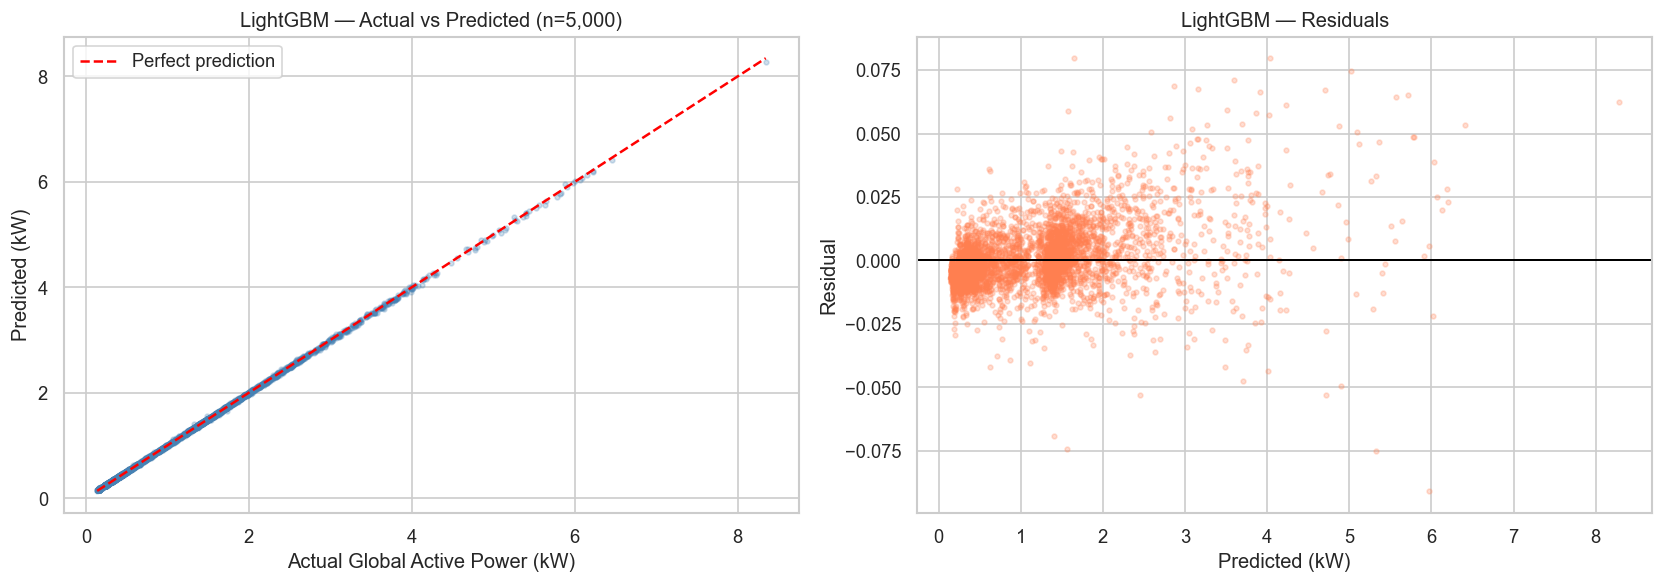

In [23]:
# ── Actual vs Predicted scatter (best model = LightGBM) ──────────────────────
sample_n = 5000
idx = np.random.choice(len(y_test), sample_n, replace=False)
y_s = np.array(y_test)[idx]
p_s = y_pred_lgb[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_s, p_s, alpha=0.25, s=8, color="steelblue")
mn, mx = y_s.min(), y_s.max()
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Global Active Power (kW)")
axes[0].set_ylabel("Predicted (kW)")
axes[0].set_title(f"LightGBM — Actual vs Predicted (n={sample_n:,})")
axes[0].legend()

# Residuals
resid = y_s - p_s
axes[1].scatter(p_s, resid, alpha=0.25, s=8, color="coral")
axes[1].axhline(0, color="black", linewidth=1.2)
axes[1].set_xlabel("Predicted (kW)")
axes[1].set_ylabel("Residual")
axes[1].set_title("LightGBM — Residuals")

plt.tight_layout()
plt.show()

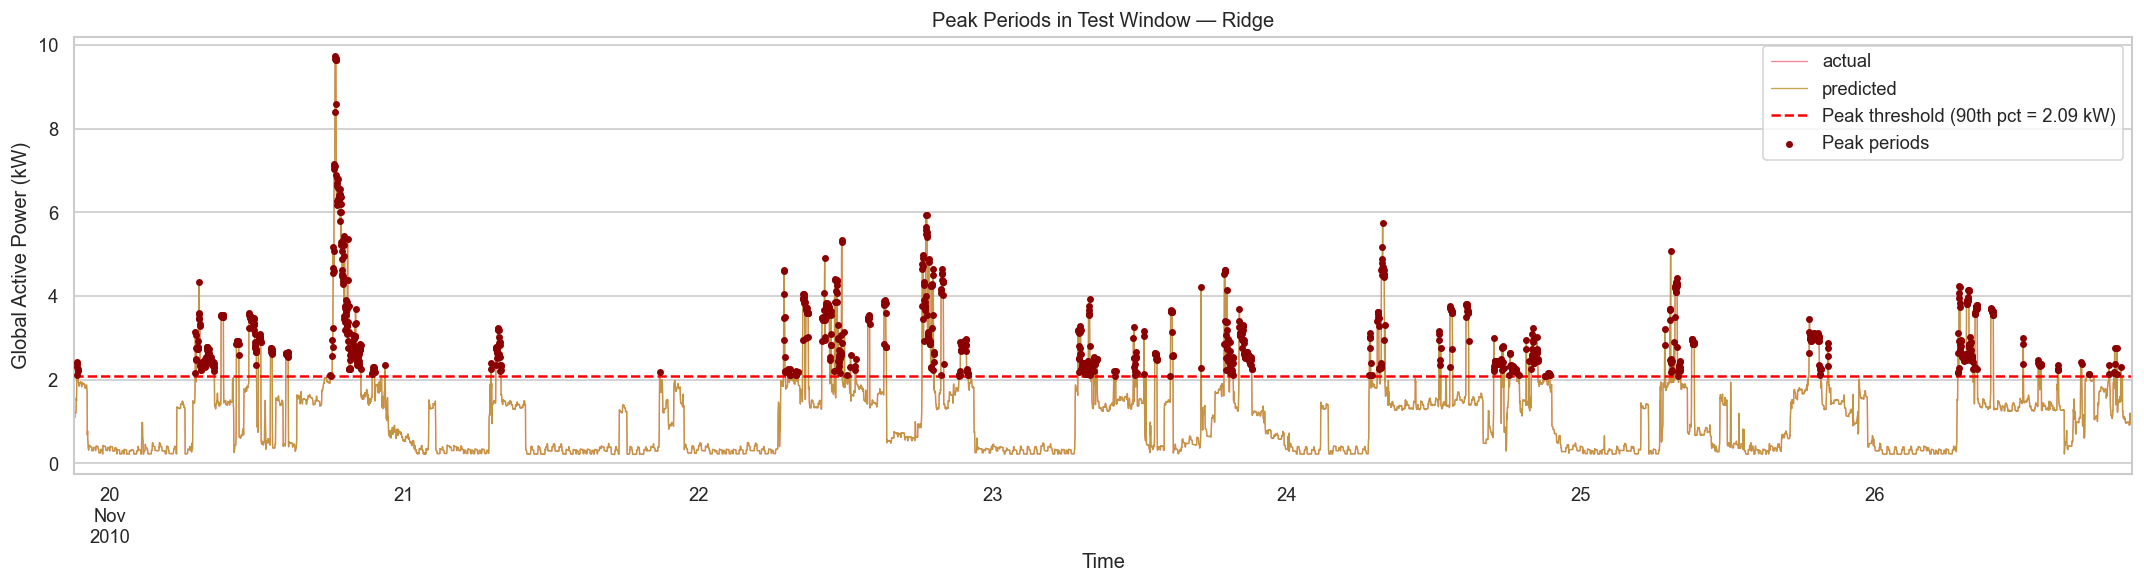

Detected peak periods: 40,826 (10.0%)
Daily time-of-day classifier accuracy: 0.979
Recommended backup window (next day): 06:00 - 11:59
Predicted time of day: Morning


In [24]:
# ── Peak-demand detection + next-day time-of-day prediction ───────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Pick the best regressor dynamically from the already-computed test results.
model_preds = {
    "Ridge": y_pred_ridge,
    "RandomForest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "StackingEnsemble": y_pred_stack,
}
best_model_name = max(results.items(), key=lambda kv: kv[1]["R²"])[0]
best_pred = model_preds[best_model_name]

comparison_df = pd.DataFrame(
    {"actual": y_test.values, "predicted": best_pred}, index=y_test.index
)
peak_threshold = comparison_df["actual"].quantile(0.90)
comparison_df["is_peak"] = comparison_df["actual"] >= peak_threshold
peak_periods = comparison_df[comparison_df["is_peak"]].copy()

fig, ax = plt.subplots(figsize=(18, 5))
comparison_df[["actual", "predicted"]].tail(7 * 24 * 60).plot(
    ax=ax, linewidth=0.8, alpha=0.85
)
ax.axhline(
    peak_threshold,
    color="red",
    linestyle="--",
    label=f"Peak threshold (90th pct = {peak_threshold:.2f} kW)",
)
if not peak_periods.empty:
    recent_peaks = peak_periods.tail(7 * 24 * 60)
    ax.scatter(
        recent_peaks.index,
        recent_peaks["actual"],
        color="darkred",
        s=10,
        label="Peak periods",
        zorder=4,
    )
ax.set_title(f"Peak Periods in Test Window — {best_model_name}")
ax.set_ylabel("Global Active Power (kW)")
ax.set_xlabel("Time")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Detected peak periods: {len(peak_periods):,} ({len(peak_periods) / len(comparison_df) * 100:.1f}%)"
)

# Daily time-of-day prediction on hourly-resampled data (easier than 24-way peak-hour classification)
df_hourly = df.resample("1h").mean().dropna().copy()
daily_df = (
    df_hourly.assign(date=df_hourly.index.date)
    .groupby("date")
    .agg(
        day_mean=("Global_active_power", "mean"),
        day_max=("Global_active_power", "max"),
        day_std=("Global_active_power", "std"),
        peak_hour=("Global_active_power", lambda s: int(s.idxmax().hour)),
    )
)

daily_df.index = pd.to_datetime(daily_df.index)
daily_df["day_of_week"] = daily_df.index.dayofweek
daily_df["month"] = daily_df.index.month
daily_df["is_weekend"] = (daily_df["day_of_week"] >= 5).astype(int)
for c in ["day_mean", "day_max", "day_std"]:
    daily_df[f"prev_{c}"] = daily_df[c].shift(1)

# Convert to four broader and more learnable classes.
def peak_hour_to_time_of_day(hour: int) -> int:
    if hour < 6:
        return 0  # Night
    if hour < 12:
        return 1  # Morning
    if hour < 18:
        return 2  # Afternoon
    return 3  # Evening


def time_of_day_to_label(idx: int) -> str:
    return {0: "Night", 1: "Morning", 2: "Afternoon", 3: "Evening"}.get(idx, "Unknown")


def time_of_day_to_window(idx: int) -> tuple[int, int]:
    return {
        0: (0, 5),
        1: (6, 11),
        2: (12, 17),
        3: (18, 23),
    }.get(idx, (0, 23))


def time_of_day_to_representative_hour(idx: int) -> int:
    return {0: 2, 1: 9, 2: 15, 3: 21}.get(idx, 12)


daily_df["peak_time_of_day"] = daily_df["peak_hour"].apply(peak_hour_to_time_of_day)

daily_df = daily_df.dropna().copy()
peak_feature_cols = [c for c in daily_df.columns if c != "peak_time_of_day"]
split_daily = int(len(daily_df) * 0.8)
X_peak_train = daily_df.iloc[:split_daily][peak_feature_cols]
y_peak_train = daily_df.iloc[:split_daily]["peak_time_of_day"]
X_peak_test = daily_df.iloc[split_daily:][peak_feature_cols]
y_peak_test = daily_df.iloc[split_daily:]["peak_time_of_day"]

peak_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
peak_model.fit(X_peak_train, y_peak_train)
y_peak_pred = peak_model.predict(X_peak_test)
peak_hour_accuracy = accuracy_score(y_peak_test, y_peak_pred)

latest_features_daily = daily_df.iloc[-1][peak_feature_cols].to_frame().T
predicted_peak_time_of_day_next_day = int(peak_model.predict(latest_features_daily)[0])
predicted_peak_hour_next_day = time_of_day_to_representative_hour(
    predicted_peak_time_of_day_next_day
)
backup_start, backup_end = time_of_day_to_window(predicted_peak_time_of_day_next_day)

print(f"Daily time-of-day classifier accuracy: {peak_hour_accuracy:.3f}")
print(
    f"Recommended backup window (next day): {backup_start:02d}:00 - {backup_end:02d}:59"
)
print(
    f"Predicted time of day: {time_of_day_to_label(predicted_peak_time_of_day_next_day)}"
)


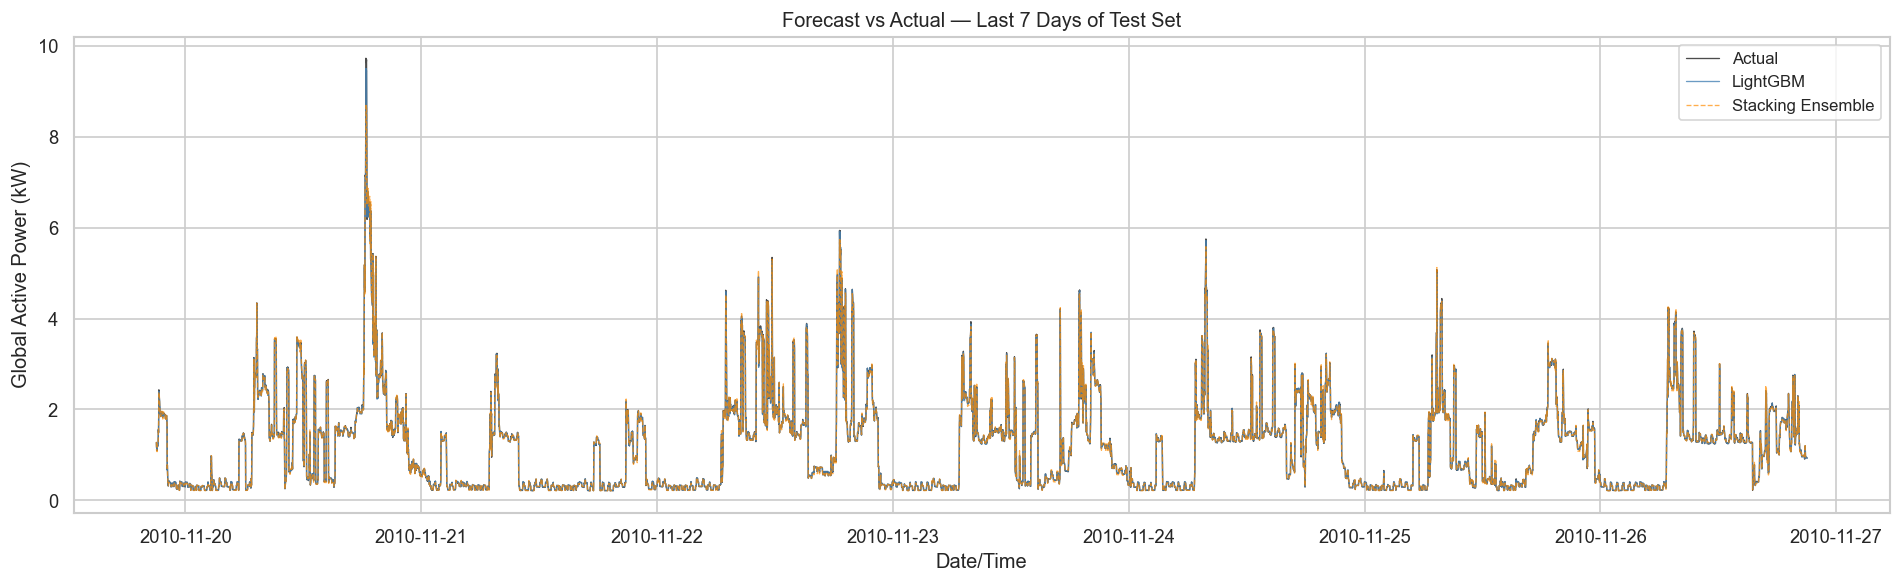

In [25]:
# ── Time-series forecast plot (last 7 days) ───────────────────────────────────
last_7d = 7 * 24 * 60  # 7 days in minutes
ts_idx = df_feat.index[split_idx:][-last_7d:]
ts_y = np.array(y_test)[-last_7d:]
ts_lgb = y_pred_lgb[-last_7d:]
ts_stack = y_pred_stack[-last_7d:]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts_idx, ts_y, color="black", alpha=0.7, linewidth=0.8, label="Actual")
ax.plot(ts_idx, ts_lgb, color="steelblue", alpha=0.8, linewidth=0.8, label="LightGBM")
ax.plot(
    ts_idx,
    ts_stack,
    color="darkorange",
    alpha=0.7,
    linewidth=0.8,
    linestyle="--",
    label="Stacking Ensemble",
)
ax.set_xlabel("Date/Time")
ax.set_ylabel("Global Active Power (kW)")
ax.set_title("Forecast vs Actual — Last 7 Days of Test Set")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

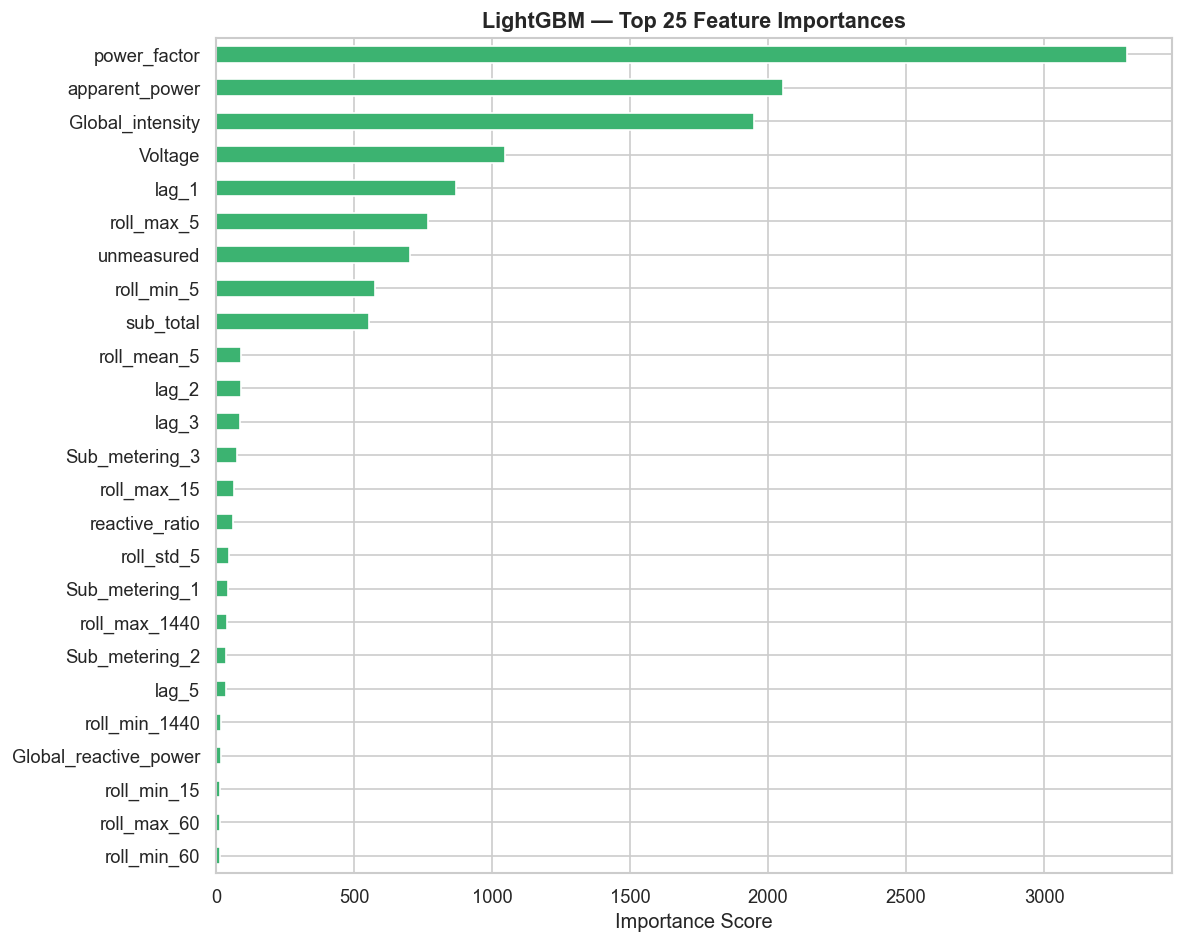

In [26]:
# ── Feature importance (LightGBM top 25) ─────────────────────────────────────
imp = pd.Series(lgb_model.feature_importances_, index=FEATURES)
top25 = imp.nlargest(25).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top25.plot.barh(ax=ax, color="mediumseagreen", edgecolor="white")
ax.set_title("LightGBM — Top 25 Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [28]:
# ── Save models, metrics, and app artifact ────────────────────────────────────
import joblib

from src.config import (
    ARTIFACT_PATH,
    COMPARISON_PATH,
    METRICS_PATH,
    PEAK_PERIODS_PATH,
    MODEL_EXPORT_DIR,
)

MODEL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

# Rebuild a save-friendly metrics table that includes the notebook's ensemble.
predictions_map = {
    "Ridge": y_pred_ridge,
    "RandomForest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "StackingEnsemble": y_pred_stack,
    "Weighted Ensemble": (y_pred_rf + y_pred_xgb + y_pred_lgb) / 3.0,
}


def summarize(name, yt, yp):
    den = np.abs(yt - yt.mean()).sum()
    rae = float(np.abs(yt - yp).sum() / den) if den > 0 else 0.0
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(yt, yp)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "R2": float(r2_score(yt, yp)),
        "MAPE": float(np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-8))) * 100),
        "RAE": rae,
        "Accuracy": (1.0 - rae) * 100,
    }


results_rows = [
    summarize(name, y_test.values, pred) for name, pred in predictions_map.items()
]
results_df_save = pd.DataFrame(results_rows).sort_values("RMSE").reset_index(drop=True)
best_model_name_save = str(results_df_save.iloc[0]["Model"])
ensemble_models_save = {
    "Ridge": ridge,
    "RandomForest": rf,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
}
ensemble_weights_save = {name: 0.0 for name in ensemble_models_save}
ensemble_weights_save.update(
    {"RandomForest": 1 / 3, "XGBoost": 1 / 3, "LightGBM": 1 / 3}
)

if best_model_name_save == "Weighted Ensemble":
    best_model_save = None
    best_pred_save = predictions_map[best_model_name_save]
    # Keep the app-compatible ensemble branch active.
    app_best_model_name = "Weighted Ensemble"
else:
    best_model_save = {
        "Ridge": ridge,
        "RandomForest": rf,
        "XGBoost": xgb_model,
        "LightGBM": lgb_model,
        "StackingEnsemble": None,
    }[best_model_name_save]
    best_pred_save = predictions_map[best_model_name_save]
    app_best_model_name = best_model_name_save

comparison_df_save = pd.DataFrame(
    {"datetime": y_test.index, "actual": y_test.values, "predicted": best_pred_save}
).set_index("datetime")
peak_threshold_save = comparison_df_save["actual"].quantile(0.90)
peak_periods_save = comparison_df_save[
    comparison_df_save["actual"] >= peak_threshold_save
].copy()

# Daily peak-period artifact for backup scheduling.
daily_peak_comparison_df_save = pd.DataFrame(
    {
        "date": daily_df.index[split_daily:],
        "actual_peak_time_of_day": y_peak_test.values,
        "predicted_peak_time_of_day": y_peak_pred,
    }
).set_index("date")

time_of_day_labels = {0: "Night", 1: "Morning", 2: "Afternoon", 3: "Evening"}


def time_of_day_to_window(idx: int) -> tuple[int, int]:
    return {
        0: (0, 5),
        1: (6, 11),
        2: (12, 17),
        3: (18, 23),
    }.get(idx, (0, 23))


def time_of_day_to_representative_hour(idx: int) -> int:
    return {0: 2, 1: 9, 2: 15, 3: 21}.get(idx, 12)


# Export individual model files and an app-compatible bundle.
model_paths = {}
for name, model in ensemble_models_save.items():
    model_path = MODEL_EXPORT_DIR / f"{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, model_path)
    model_paths[name] = str(model_path)

best_model_path = (
    MODEL_EXPORT_DIR / f"best_{app_best_model_name.lower().replace(' ', '_')}.joblib"
)
if best_model_save is not None:
    joblib.dump(best_model_save, best_model_path)
else:
    joblib.dump(
        {
            "best_model_name": app_best_model_name,
            "models": ensemble_models_save,
            "weights": ensemble_weights_save,
        },
        best_model_path,
    )
model_paths["best_model"] = str(best_model_path)

# ensure backup_power_time_window is defined (don't overwrite if already set)
if "backup_power_time_window" not in globals():
    # fallback to backup_start/backup_end if available
    try:
        backup_power_time_window = (int(backup_start), int(backup_end))
    except Exception:
        # final fallback: full-day window
        backup_power_time_window = (0, 23)

artifact_payload = {
    "results_df": results_df_save,
    "comparison_df": comparison_df_save,
    "peak_periods": peak_periods_save,
    "peak_threshold": float(peak_threshold_save),
    "best_model_name": app_best_model_name,
    "best_model": best_model_save,
    "ensemble_models": ensemble_models_save,
    "ensemble_weights": ensemble_weights_save,
    "feature_cols": list(X.columns),
    "latest_features": X.iloc[-1],
    "latest_timestamp": str(df_feat.index[-1]),
    "target_col": TARGET,
    "daily_peak_model": {"RandomForest": peak_model},
    "daily_peak_ensemble_weights": {"RandomForest": 1.0},
    "daily_peak_feature_cols": peak_feature_cols,
    "latest_daily_features": latest_features_daily,
    "daily_peak_accuracy": float(peak_hour_accuracy),
    "daily_peak_comparison_df": daily_peak_comparison_df_save,
    "predicted_peak_time_of_day_next_day": int(predicted_peak_time_of_day_next_day),
    "predicted_peak_time_of_day_label": time_of_day_labels[int(predicted_peak_time_of_day_next_day)],
    "predicted_peak_hour_next_day": int(predicted_peak_hour_next_day),
    "backup_power_time_window": backup_power_time_window,
    "model_paths": model_paths,
    "best_metrics": results_df_save.iloc[0].to_dict(),
}

joblib.dump(artifact_payload, ARTIFACT_PATH)
results_df_save.to_csv(METRICS_PATH, index=False)
comparison_df_save.to_csv(COMPARISON_PATH)
peak_periods_save.to_csv(PEAK_PERIODS_PATH)

print("✅ Saved new model artifact and reports")
print(f"Artifact : {ARTIFACT_PATH}")
print(f"Metrics  : {METRICS_PATH}")
print(f"Compare  : {COMPARISON_PATH}")
print(f"Peaks    : {PEAK_PERIODS_PATH}")
print("Top metrics:")
print(results_df_save.head(5).to_string(index=False))


✅ Saved new model artifact and reports
Artifact : /home/temi/Documents/clones/End-to-End-Smart-Power/models/power_forecast.joblib
Metrics  : /home/temi/Documents/clones/End-to-End-Smart-Power/reports/model_metrics.csv
Compare  : /home/temi/Documents/clones/End-to-End-Smart-Power/reports/test_comparison.csv
Peaks    : /home/temi/Documents/clones/End-to-End-Smart-Power/reports/peak_periods.csv
Top metrics:
            Model      MAE     RMSE       R2     MAPE      RAE  Accuracy
            Ridge 0.000028 0.000462 1.000000 0.005471 0.000040 99.996020
         LightGBM 0.007801 0.011412 0.999838 1.231817 0.011011 98.898868
          XGBoost 0.008989 0.012909 0.999792 1.538459 0.012689 98.731138
 StackingEnsemble 0.020755 0.029696 0.998900 3.282084 0.029297 97.070329
Weighted Ensemble 0.020755 0.029696 0.998900 3.282084 0.029297 97.070329


---
### Notes
- The daily peak model now predicts a broader time-of-day bucket instead of a 24-class peak hour, which is usually much easier to learn and more stable.
- The notebook overwrites `models/power_forecast.joblib` and the CSV reports in `reports/` whenever the save cell is run.
- Re-run the notebook after changing features or models so Streamlit picks up the refreshed artifact.

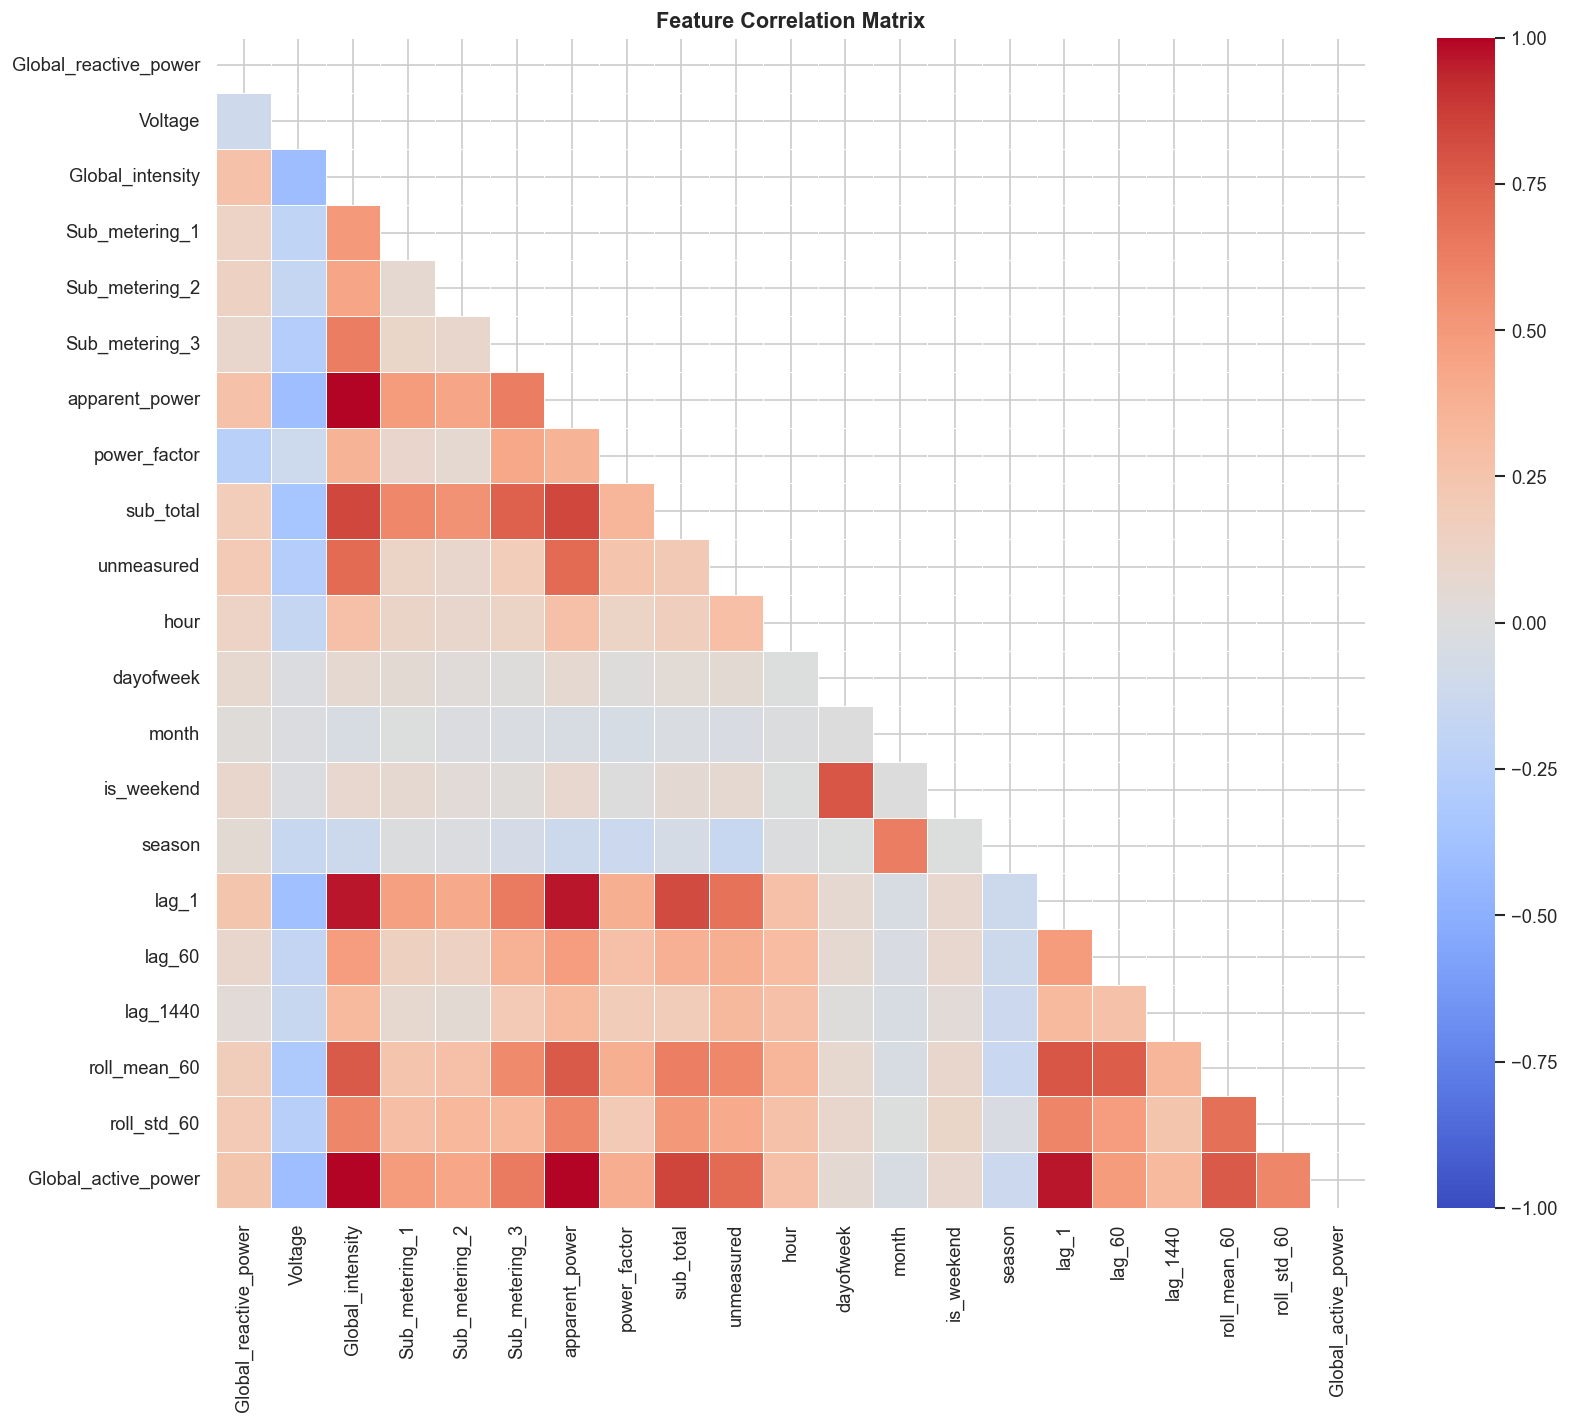

In [29]:
# ── Correlation heat-map of engineered features ───────────────────────────────
core_feats = [
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "apparent_power",
    "power_factor",
    "sub_total",
    "unmeasured",
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "season",
    "lag_1",
    "lag_60",
    "lag_1440",
    "roll_mean_60",
    "roll_std_60",
    TARGET,
]

corr = df_feat[core_feats].sample(50_000, random_state=SEED).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3,
    ax=ax,
    vmin=-1,
    vmax=1,
)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()